**Install Packages**

In [1]:
!pip install tensorflow
!pip install scikit-learn
!pip install onnx
!pip install onnxruntime
!pip install skl2onnx
!pip install tf2onnx
!pip install pandas seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 15.8 MB/s eta 0:00:00


**Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Load Dataset**

In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


**Dataset Exploration**

In [4]:
df = pd.DataFrame(
    X,
    columns=data.feature_names
)

df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Class Distribution**

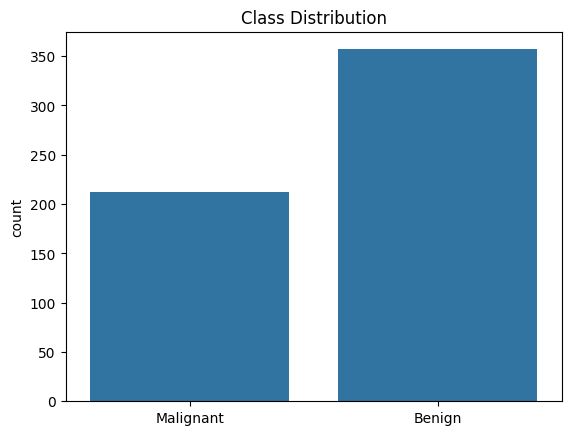

In [5]:
sns.countplot(x=y)

plt.xticks(
    [0,1],
    ["Malignant","Benign"]
)

plt.title("Class Distribution")
plt.show()

**Correlation Heatmap**

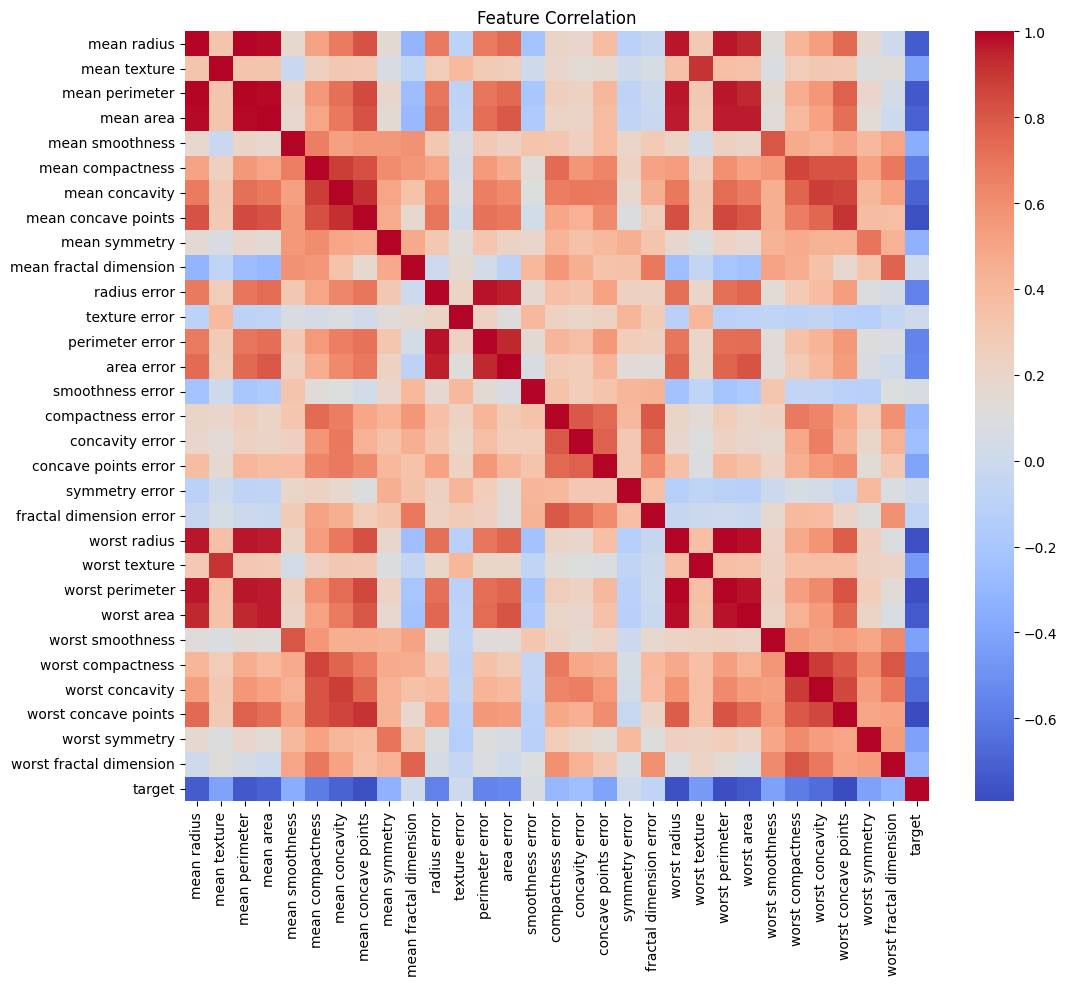

In [6]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

**Train/Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Standardization**

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Machine Learning Models**

In [9]:
# SVM
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    probability=True
)

svm.fit(
    X_train,
    y_train
)

SVC(probability=True)

In [10]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

KNeighborsClassifier()

In [11]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [12]:
# Deep Learning Model
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

dnn = Sequential([

    Dense(
        64,
        activation="relu",
        input_shape=(30,)
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
dnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history = dnn.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7720 - loss: 0.5012 - val_accuracy: 0.9121 - val_loss: 0.3367
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9286 - loss: 0.2455 - val_accuracy: 0.9560 - val_loss: 0.2083
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9478 - loss: 0.1705 - val_accuracy: 0.9560 - val_loss: 0.1578
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9560 - loss: 0.1344 - val_accuracy: 0.9560 - val_loss: 0.1284
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9670 - loss: 0.1132 - val_accuracy: 0.9670 - val_loss: 0.1098
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9753 - loss: 0.0984 - val_accuracy: 0.9670 - val_loss: 0.0973
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0896 - val_accuracy: 0.9780 - val_loss: 0.0862
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.0814 - val_accuracy: 0.9780 - val_

# **Training Visualization**

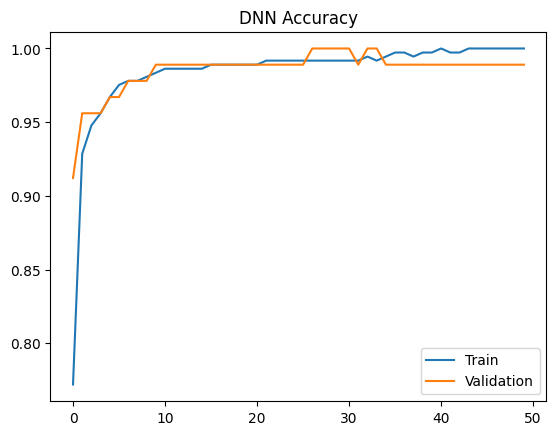

In [17]:
plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.legend(
    ["Train","Validation"]
)

plt.title(
    "DNN Accuracy"
)

plt.show()

# **Convert ML Models to ONNX**

In [21]:
# SVM
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

initial_type = [
    ("input",
     FloatTensorType([None,30]))
]

onnx_svm = convert_sklearn(
    svm,
    initial_types=initial_type
)

with open(
    "svm-cancer.onnx",
    "wb"
) as f:

    f.write(
        onnx_svm.SerializeToString()
    )

In [22]:
# KNN
onnx_knn = convert_sklearn(
    knn,
    initial_types=initial_type
)

with open(
    "knn-cancer.onnx",
    "wb"
) as f:

    f.write(
        onnx_knn.SerializeToString()
    )

In [23]:
# Random Forest
onnx_rf = convert_sklearn(
    rf,
    initial_types=initial_type
)

with open(
    "rf-cancer.onnx",
    "wb"
) as f:

    f.write(
        onnx_rf.SerializeToString()
    )

In [24]:
# Convert DNN to ONNX For TensorFlow 2.20+

import tf2onnx
import tensorflow as tf

@tf.function
def model_fn(x):
    return dnn(x)

onnx_model, _ = tf2onnx.convert.from_function(
    model_fn,
    input_signature=[
        tf.TensorSpec(
            [None,30],
            tf.float32,
            name="input"
        )
    ],
    opset=13
)

with open(
    "dnn-cancer.onnx",
    "wb"
) as f:

    f.write(
        onnx_model.SerializeToString()
    )

# **ONNX Runtime Inference**

In [25]:
import onnxruntime as ort

def onnx_predict(
    model_path,
    X
):

    session = ort.InferenceSession(
        model_path
    )

    input_name = session.get_inputs()[0].name

    outputs = session.run(
        None,
        {
            input_name:
            X.astype(np.float32)
        }
    )

    return outputs

# **Metrics Function**

In [27]:
from sklearn.metrics import confusion_matrix

def calculate_metrics(
    y_true,
    y_pred
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    acc = (
        tp+tn
    ) / (
        tp+tn+fp+fn
    )

    sen = tp/(tp+fn)

    spec = tn/(tn+fp)

    mcc = (
        (tp*tn) -
        (fp*fn)
    ) / np.sqrt(
        (tp+fp)*
        (tp+fn)*
        (tn+fp)*
        (tn+fn)
    )

    return [
        acc,
        sen,
        spec,
        mcc
    ]

# **Evaluate All Models**

In [28]:
svm_pred = svm.predict(X_test)
knn_pred = knn.predict(X_test)
rf_pred = rf.predict(X_test)

dnn_pred = (
    dnn.predict(X_test)
    > 0.5
).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


# **Results Table**

In [29]:
results = pd.DataFrame(
    columns=[
        "ACC",
        "SEN",
        "SPEC",
        "MCC"
    ]
)

results.loc[
    "SVM"
] = calculate_metrics(
    y_test,
    svm_pred
)

results.loc[
    "KNN"
] = calculate_metrics(
    y_test,
    knn_pred
)

results.loc[
    "Random Forest"
] = calculate_metrics(
    y_test,
    rf_pred
)

results.loc[
    "DNN"
] = calculate_metrics(
    y_test,
    dnn_pred
)

In [30]:
print(
    results.round(4)
)

                  ACC     SEN    SPEC     MCC
SVM            0.9825  0.9861  0.9762  0.9623
KNN            0.9561  0.9722  0.9286  0.9054
Random Forest  0.9561  0.9722  0.9286  0.9054
DNN            0.9649  0.9583  0.9762  0.9260


# **Confusion Matrix Visualization**

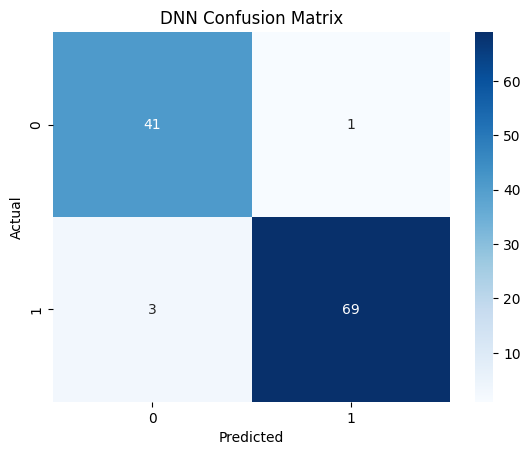

In [31]:
cm = confusion_matrix(
    y_test,
    dnn_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "DNN Confusion Matrix"
)

plt.show()

# **Performance Comparison**

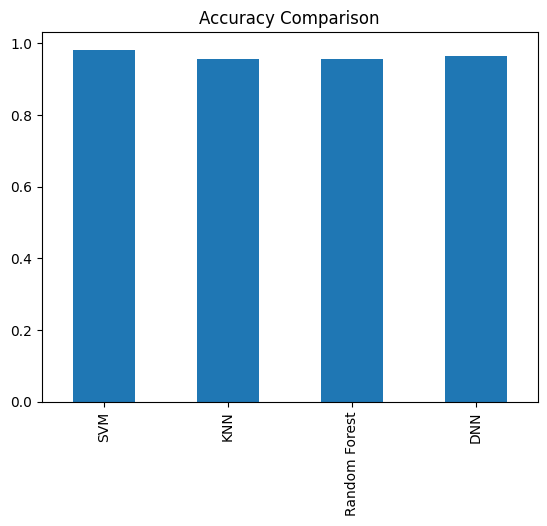

In [32]:
# Accuracy

results["ACC"].plot(
    kind="bar"
)

plt.title(
    "Accuracy Comparison"
)

plt.show()

**Sensitivity**

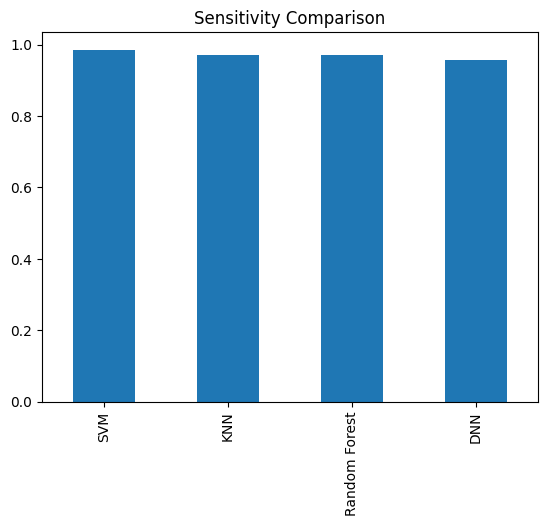

In [33]:
results["SEN"].plot(
    kind="bar"
)

plt.title(
    "Sensitivity Comparison"
)

plt.show()

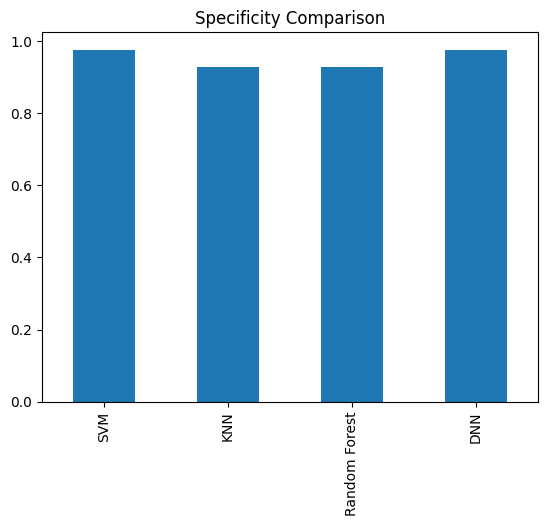

In [34]:
# Specificity

results["SPEC"].plot(
    kind="bar"
)

plt.title(
    "Specificity Comparison"
)

plt.show()

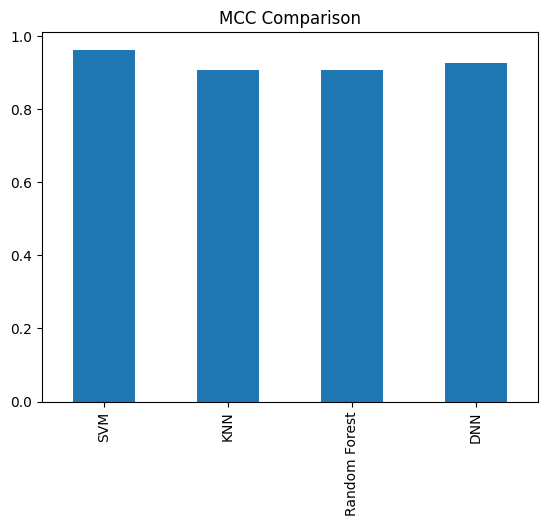

In [35]:
# MCC

results["MCC"].plot(
    kind="bar"
)

plt.title(
    "MCC Comparison"
)

plt.show()